# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Jonathan Delen Hosea
- **Email:** cdcc002d6y0817@student.devacademy.id
- **ID Dicoding:** CDCC002D6Y0817

## Menentukan Pertanyaan Bisnis

- Bagaimana perbedaan tren demografi waktu penyewaan sepeda antara hari kerja (*workingday*) dan hari libur (*holiday/weekend*) selama tahun 2011-2012, lalu pada kelompok waktu mana (clustering) terjadi puncak penyewaan tertinggi?
- Bagaimana pengaruh kondisi cuaca dan kategori suhu (binning) terhadap jumlah pengguna biasa (*casual*) dan pengguna terdaftar (*registered*) selama tahun 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [24]:
# Load data day
day_df  = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Tampilkan 5 baris pertama dengan function head.
display(day_df.head())
print()
display(hour_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kedua dataset memiliki struktur yang hampir mirip. Perbedaannya hanyalah data hour_df memiliki kolom tambahan `hr` (jam).
- Data cuaca seperti suhu (`temp` , `atemp`), kelembaban (`hum`), dan kecepatan angin (`windspeed`) telah dinormalisasi sehingga nilainya berkisar antara 0 sampai 1.

### Assessing Data

In [25]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
day_df.info()
print()
hour_df.info()

# Mengecek dataset menggunakan isnull().sum()
print("\nMissing value data day: \n", day_df.isnull().sum())
print("\nMissing value data hour: \n", hour_df.isnull().sum())

# Mengecek dataset menggunakan duplicated().sum()
print("\nJumlah duplikasi data day: ", day_df.duplicated().sum())
print("Jumlah duplikasi data hour: ", hour_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (to

**Insight:**
- Kolom `dteday`  (tanggal) terbaca sebagai *object* (string) sehingga perlu diubah menjadi *datetime* agar bisa diolah dalam analisis time-series. Selain itu, beberapa kolom kategoris seperti (`season`, `mnth`, `holiday`, `weekday`, `workingday`, dan `weathersit`) terbaca sebagai *int64* (integer) sehingga perlu diubah menjadi *category* agar tidak disalahartikan oleh model.
- Tidak ditemukan adanya missing value ataupun duplikasi pada kedua dataset sehingga eksekusi dropna() dan drop_duplicates() tidak diperlukan pada tahap cleaning data.

### Cleaning Data

In [26]:
# Memperbaiki tipe data dteday (tanggal)
day_df['dteday']  = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mengubah tipe data int64
categorical = ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

for col in categorical:
  day_df[col]  = day_df[col].astype('category')
  hour_df[col] = hour_df[col].astype('category')

# Mapping angka menjadi label string
# Season (musim)
season = {1: 'Spring',
          2: 'Summer',
          3: 'Fall',
          4: 'Winter'}
day_df['season']  = day_df['season'].map(season)
hour_df['season'] = hour_df['season'].map(season)

# Weather (cuaca)
weather = {1: 'Clear',
           2: 'Mist + Cloudy',
           3: 'Light Snow',
           4: 'Heavy Rain'}
day_df['weathersit']  = day_df['weathersit'].map(weather)
hour_df['weathersit'] = hour_df['weathersit'].map(weather)

# Cek hasil perubahan
print(day_df["dteday"].dtype)
display(day_df[['dteday', 'season', 'weathersit']].head())
print()
display(hour_df[['dteday', 'hr', 'season', 'weathersit']].head())

datetime64[ns]


,dteday,season,weathersit
0,2011-01-01,Spring,Mist + Cloudy
1,2011-01-02,Spring,Mist + Cloudy
2,2011-01-03,Spring,Clear
3,2011-01-04,Spring,Clear
4,2011-01-05,Spring,Clear


,dteday,hr,season,weathersit
0,2011-01-01,0,Spring,Clear
1,2011-01-01,1,Spring,Clear
2,2011-01-01,2,Spring,Clear
3,2011-01-01,3,Spring,Clear
4,2011-01-01,4,Spring,Clear


**Insight:**
- Dilakukan perbaikan tipe data pada kolom `dteday` menjadi *datetime* agar bisa diolah dalam analisis time-series. Selain itu, kolom-kolom kategoris seperti `season`, `weathersit`, dan `holiday` juga diubah menjadi tipe *category* untuk efisiensi memori dan keakuratan visualisasi.
- Dilakukan mapping pada kolom `season` dan `weathersit` untuk mengubah kode angka menjadi label string yang lebih mudah diinterpretasikan.

## Exploratory Data Analysis (EDA)

### Explore Dataset day_df & hour_df



In [27]:
# Part 1: Clustering: Manual Grouping waktu pada dataset hour_df
def group_time(hr):
  if 4 <= hr < 12:
    return 'Morning'
  if 12 <= hr < 18:
    return 'Afternoon'
  if 18 <= hr < 21:
    return 'Evening'
  else:
    return 'Night'

hour_df['time'] = hour_df['hr'].apply(group_time)
hour_df['time'] = pd.Categorical(hour_df['time'],
                                 categories=['Morning', 'Afternoon', 'Evening', 'Night'],
                                 ordered=True)

# Rata-rata sewa berdasarkan hari dan waktu
time_rental_df = hour_df.groupby(by=['workingday', 'time']).agg({
    'cnt': 'mean'
}).reset_index()

# Mapping workingday
workingday_time = {0: 'Holiday/Weekend',
                   1: 'Working Day'}
time_rental_df['workingday'] = time_rental_df['workingday'].map(workingday_time)

# Part 2: Clustering: Bining suhu pada dataset day_df
# Bagi data suhu menjadi 3 bagian sama panjang
day_df['temp_bin'] = pd.cut(day_df['temp'], bins=3, labels = ['Cold', 'Mild', 'Hot'])

# Total pengguna (casual & registered) berdasarkan cuaca dan bining suhu
weather_temp_df = day_df.groupby(by=['weathersit', 'temp_bin']).agg({
    'casual': 'sum',
    'registered': 'sum'
}).reset_index()

# Cek hasilnya
display(time_rental_df.head(8))
print
display(weather_temp_df)

/tmp/ipykernel_9462/3461112870.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_rental_df = hour_df.groupby(by=['workingday', 'time']).agg({
/tmp/ipykernel_9462/3461112870.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_temp_df = day_df.groupby(by=['weathersit', 'temp_bin']).agg({


,workingday,time,cnt
0,Holiday/Weekend,Morning,116.818331
1,Holiday/Weekend,Afternoon,356.454545
2,Holiday/Weekend,Evening,229.156522
3,Holiday/Weekend,Night,83.474766
4,Working Day,Morning,180.634357
5,Working Day,Afternoon,267.211777
6,Working Day,Evening,363.449130
7,Working Day,Night,69.410346


,weathersit,temp_bin,casual,registered
0,Clear,Cold,31971,265938
1,Clear,Mild,173136,697273
2,Clear,Hot,241239,848395
3,Mist + Cloudy,Cold,12642,120752
4,Mist + Cloudy,Mild,75905,395445
5,Mist + Cloudy,Hot,81229,310885
6,Light Snow,Cold,471,4957
7,Light Snow,Mild,1889,22255
8,Light Snow,Hot,1535,6762


Pada tahap ini diterapkan dua metode clustering untuk menemukan pola perilaku pengguna, yaitu:

1. **Manual grouping (data waktu pada hour_df):**
Data `hr` yang berformat 24 jam dikelompokkan secara manual ke dalam 4 kategori, yaitu **Morning** (04.00-11.59), **Afternoon** (12.00-17.59), **Evening** (18.00-20.59), dan **Night** (21.00-03.59). Pemilihan pukul 04.00 sebagai awal cluster **Morning** didasarkan pada mulainya aktivitas komuter yang bersiap berangkat kerja sehingga pengelompokan ini dapat memisahkan lalu lintas pekerja (pagi/sore) dengan lalu lintas rekreasi (siang).

2. **Bining (data suhu pada day_df):**
Data `temp` yang berisi nilai kontinu yang telah dinormalisasi dipotong langsung menjadi 3 interval sama rata menggunakan fungsi `pd.cut` sehingga menghasilkan kategori **Cold**, **Mild**, dan **Hot**. Metode tersebut dipilih agar pembagian jarak interval tidak bias dan proporsional. Selain itu, batas yang diterapkan juga selaras dengan keadaan iklim di dunia nyata (misalnya **Mild** berkisar antara 7.5°C-23.5°C) sehingga memungkinkan untuk mengukur sensitivitas pengguna terhadap cuaca secara objektif


**Insight:**
- Pada hari kerja (*Working Day*), puncak penyewaan tertinggi terjadi pada **Evening** (rata-rata 363 sewa), baru disusul oleh **Afternoon** (267 sewa), **Morning** (180 sewa), dan **Night** (69 sewa). Hal ini mengindikasikan bahwa selain digunakan untuk pulang kerja (komuter sore), sepeda juga aktif digunakan untuk mobilitas tengah hari, misalnya untuk jam makan siang.
- Sementara itu, pada hari libur (*Holiday/Weekend*), puncak penyewaannya bergeser ke **Afternoon** (rata-rata 356 sewa), baru disusul oleh **Evening** (229 sewa), **Morning** (116 sewa), dan **Night** (83 sewa). Perubahan ini menunjukkan bahwa pengguna lebih memilih berekreasi dengan waktu yang lebih santai daripada saat hari kerja.

- Secara umum, kombinasi cuaca cerah (**Clear**) dengan suhu **Hot** atau **Mild** menjadi kombinasi paling ideal dalam menghasilkan volume penyewaan tertinggi.
- Ketika suhu berubah menjadi **Cold** atau cuaca memburuk (**Mist + Cloudy** dan **Light Snow**), kelompok pengguna *casual* mengalami penurunan yang sangat drastis. Namun, pengguna *registered* memiliki "daya tahan" yang lebih kuat dan tetap menyewa dalam jumlah yang cukup besar (misalnya 120752 sewa pada **Mist + Cloudy**). Hal ini menunjukkan bahwa pengguna *registered* sangat bergantung pada sepeda untuk rutinitas harian mereka tanpa memedulikan kondisi cuaca.

- Kategori cuaca tingkat 4 (**Heavy Rain**) tidak muncul sama sekali. Hal ini dikarenakan pada dataset `day_df` tidak ada satu hari penuh yang mengalami cuaca ekstrem konstan selama 24 jam berturut-turut pada tahun 2011-2012

### Explore Data Distribution

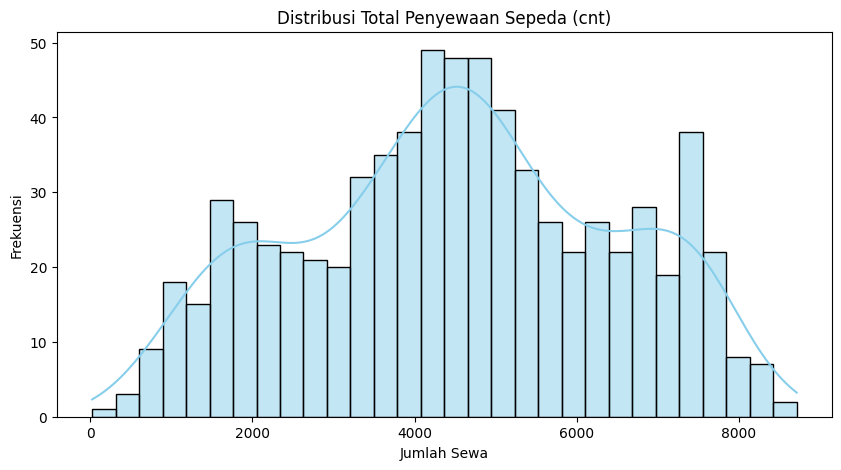

In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(day_df['cnt'],
             bins=30,
             kde=True,
             color='skyblue')
plt.title('Distribusi Total Penyewaan Sepeda (cnt)')
plt.xlabel('Jumlah Sewa')
plt.ylabel('Frekuensi')
plt.show()

**Insight:**
- Berdasarkan grafik di atas, terlihat bahwa jumlah total penyewaan sepeda harian (`cnt`) memiliki persebaran yang cukup bervariasi. Tidak semua hari memiliki jumlah sewa yang sama dan terdapat frekuensi yang tinggi pada rentang jumlah sewa tertentu. Hal ini mengindikasikan bahwa permintaan penyewaan sepeda sangat fluktuatif dan dipengaruhi oleh faktor-faktor eksternal, seperti cuaca, suhu, atau hari libur.

### Explore Weather Influence

/tmp/ipykernel_9462/843471079.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weathersit',


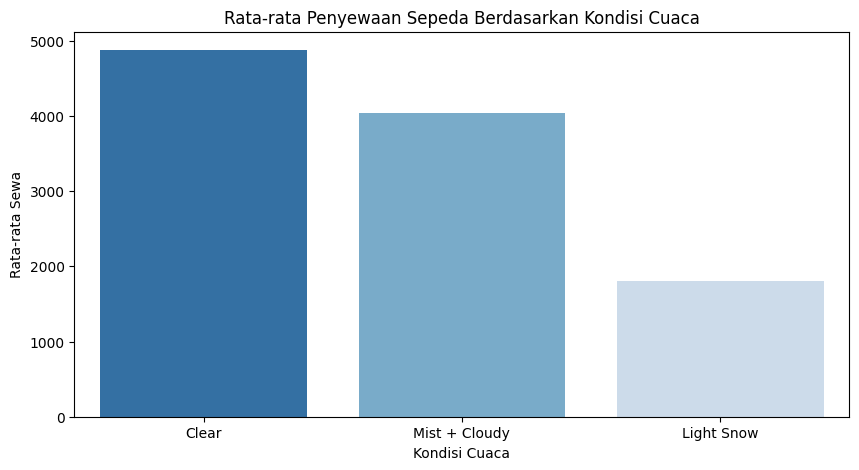

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(x='weathersit',
            y='cnt',
            data=day_df,
            palette='Blues_r',
            errorbar=None)
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Sewa')
plt.show()

**Insight:**
- Grafik di atas menunjukkan bahwa kondisi cuaca memiliki dampak yang sangat signifikan terhadap jumlah penyewaan sepeda. Terlihat bahwa cuaca yang cerah memiliki rata-rata penyewaan tertinggi. Namun, begitu cuaca mulai memburuk (mendung dan hujan salju), jumlah penyewaan mengalami penurunan.
- Hal ini sangat logis mengingat bersepeda adalah aktivitas luar ruangan yang kenyamanannya sangat bergantung kepada cuaca.

### Explore Correlation

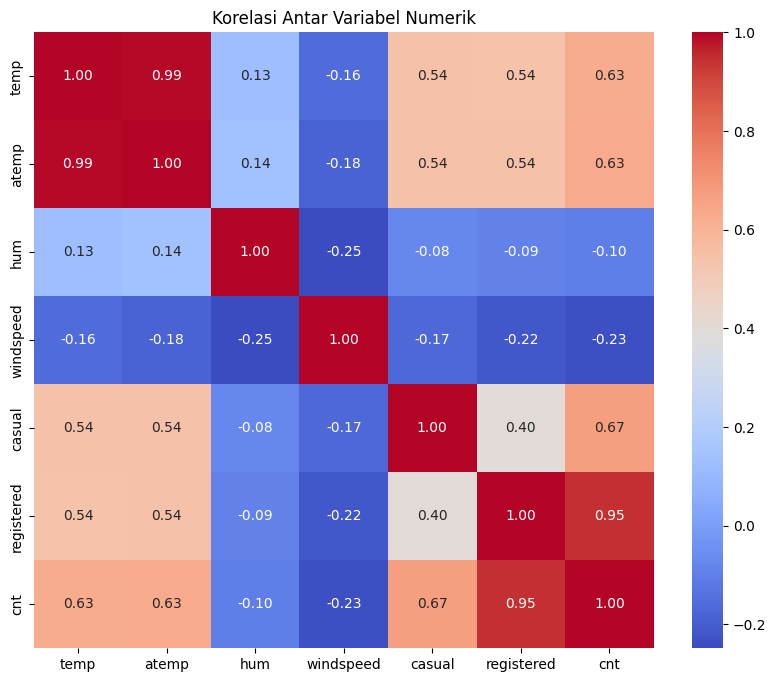

In [30]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
plt.figure(figsize=(10, 8))
sns.heatmap(day_df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

**Insight:**

Dari peta korelasi (*heatmap*) di atas, kita dapat menemukan beberapa hubungan penting:
- Suhu (`temp` & `atemp`) memiliki korelasi positif yang cukup kuat dengan total sewa (`cnt`). Artinya, semakin hangat atau ideal suhu hari itu, semakin banyak orang yang menyewa sepeda.
- Sementara itu, kelembapan (`hum`) & kecepatan Angin (`windspeed`) memiliki korelasi negatif dengan total sewa. Artinya, tingginya kelembapan udara atau angin yang terlalu kencang cenderung menurunkan minat pengguna untuk bersepeda.

### Pertanyaan 1: Bagaimana perbedaan tren demografi waktu penyewaan sepeda antara hari kerja (*workingday*) dan hari libur (*holiday/weekend*) selama tahun 2011-2012, lalu pada kelompok waktu mana (clustering) terjadi puncak penyewaan tertinggi?

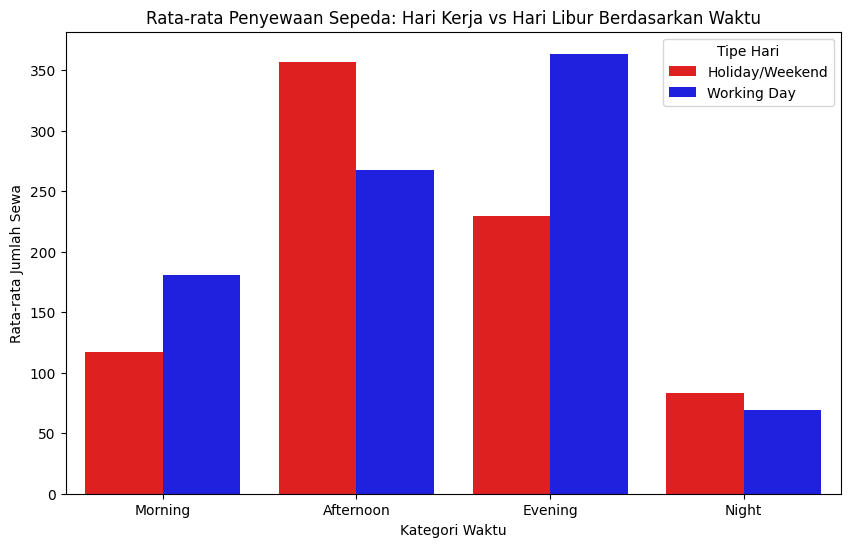

In [31]:
# Visualisasi 1: Pola Waktu vs Hari
plt.figure(figsize=(10, 6))
sns.barplot(
    data=time_rental_df,
    x='time',
    y='cnt',
    hue='workingday',
    palette=['#FF0000', '#0000FF']
)

plt.title('Rata-rata Penyewaan Sepeda: Hari Kerja vs Hari Libur Berdasarkan Waktu')
plt.xlabel('Kategori Waktu')
plt.ylabel('Rata-rata Jumlah Sewa')
plt.legend(title='Tipe Hari')
plt.show()

### Pertanyaan 2: Bagaimana pengaruh kondisi cuaca dan kategori suhu (binning) terhadap jumlah pengguna biasa (*casual*) dan pengguna terdaftar (*registered*) selama tahun 2011-2012?

/tmp/ipykernel_9462/540433236.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_impact = day_df.groupby('weathersit')[['casual', 'registered']].sum().reset_index()
/tmp/ipykernel_9462/540433236.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_impact = day_df.groupby('temp_bin')[['casual', 'registered']].sum().reset_index()


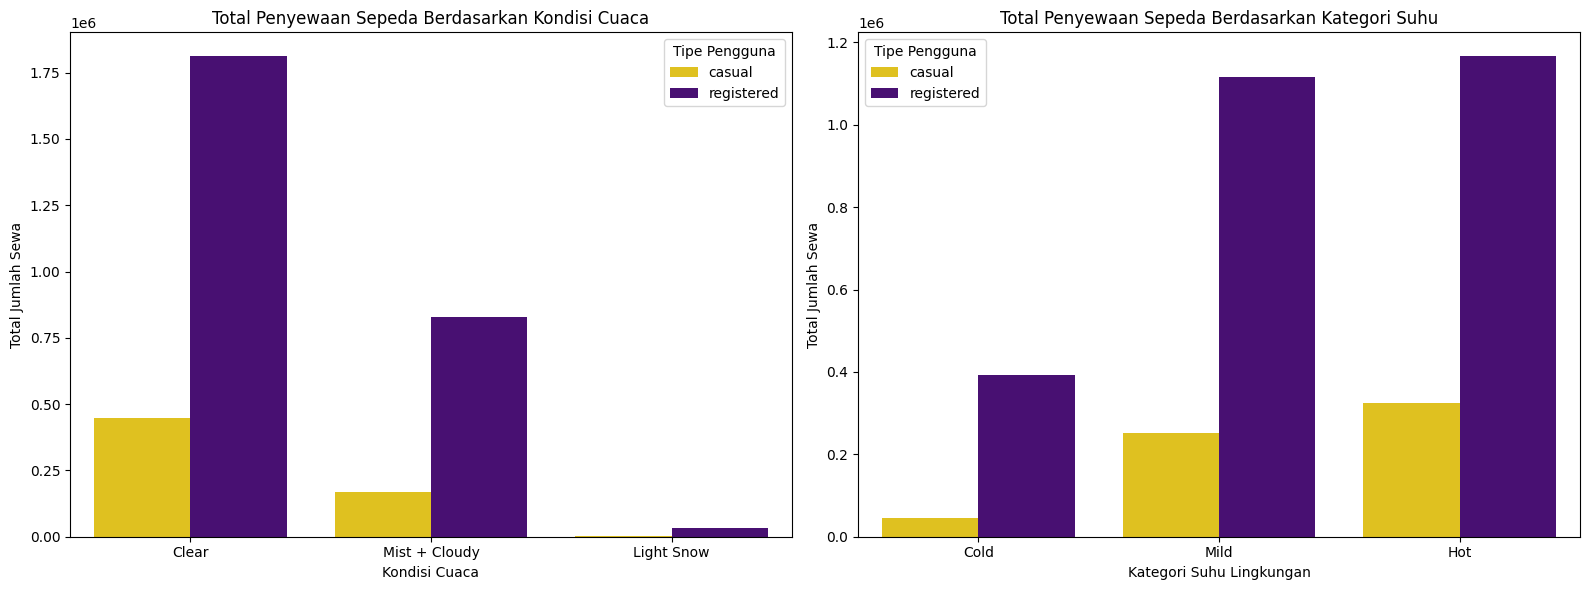

In [32]:
# Visualisasi 2: Dampak Suhu pada Tipe Pengguna
# Agregasi data
weather_impact = day_df.groupby('weathersit')[['casual', 'registered']].sum().reset_index()
temp_impact = day_df.groupby('temp_bin')[['casual', 'registered']].sum().reset_index()

# Melakukan 'melt' agar Seaborn bisa membaca kedua kolom tipe pengguna
melt_weather = pd.melt(weather_impact,
                       id_vars=['weathersit'],
                       value_vars=['casual', 'registered'],
                       var_name='user_type',
                       value_name='total_users')

melt_temp = pd.melt(temp_impact,
                    id_vars=['temp_bin'],
                    value_vars=['casual', 'registered'],
                    var_name='user_type',
                    value_name='total_users')

# 3. MEMBUAT 2 GRAFIK BERDAMPINGAN
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Total Pengguna berdasarkan Cuaca
sns.barplot(data=melt_weather,
            x='weathersit',
            y='total_users',
            hue='user_type',
            palette=['#FFD700', '#4B0082'],
            ax=ax[0])
ax[0].set_title('Total Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
ax[0].set_xlabel('Kondisi Cuaca')
ax[0].set_ylabel('Total Jumlah Sewa')
ax[0].legend(title='Tipe Pengguna')

# Grafik 2: Total Pengguna berdasarkan Suhu
sns.barplot(data=melt_temp,
            x='temp_bin',
            y='total_users',
            hue='user_type',
            palette=['#FFD700', '#4B0082'],
            ax=ax[1])
ax[1].set_title('Total Penyewaan Sepeda Berdasarkan Kategori Suhu')
ax[1].set_xlabel('Kategori Suhu Lingkungan')
ax[1].set_ylabel('Total Jumlah Sewa')
ax[1].legend(title='Tipe Pengguna')

plt.tight_layout()
plt.show()

**Insight:**

**1. Pertanyaan 1: Pola Waktu**
- Pada hari kerja (batang biru), puncak penyewaannya tertinggi terjadi pada **Evening** (pulang kantor/kuliah), yang kemudian disusul oleh **Afternoon**. Hal ini menunjukkan bahwa penggunaan sepeda sangat intensif di penghujung jam produktif sebagai sarana mobilitas harian.
- Pada hari libur (batang merah), puncak penyewaan bergeser ke **Afternoon**, baru disusul oleh **Evening**. Berbeda dengan hari kerja, tidak ada lonjakan signifikan di pagi hari. Hal ini mengindikasikan bahwa pada hari libur, sepeda lebih banyak digunakan untuk aktivitas rekreasi dan bersantai saat hari sudah siang hingga sore.

**2. Pertanyaan 2: Kondisi Cuaca**
- Volume penyewaan mencapai angka tertinggi pada cuaca **Clear**. Kondisi ini merupakan pendorong utama aktivitas bagi kedua tipe pengguna karena faktor kenyamanan berkendara.
- Terdapat perbedaan kontras pada tingkat retensi/daya tahan tipe pengguna saat cuaca memburuk ke **Light Snow**. Meskipun secara jumlah absolut keduanya menurun, pengguna *casual* hampir berhenti total (penurunan proporsional esktrem) sedangkan pengguna *registered* tetap mempertahankan volume penyewaan dasar. Hal ini menunjukkan adanya ketergatungan fungsional yang lebih tinggi pada kelompok *registered* dibandingkan dengan kelompok *casual* yang bersifat rekreasi.
- Sementara itu, kondisi **Heavy Rain** sama sekali tidak ditemukan dalam dataset. Hal ini mengindikasikan kemungkinan adanya penghentian operasional layanan atau nihilnya permintaan pada kondisi cuaca ekstrem tersebut.

**3. Pertanyaan 2: Dampak Suhu**
- Data menunjukkan adanya korelasi positif antara suhu dan volume sewa. Kategori **Hot** mencatatkan total penyewaan tertinggi, disusul oleh **Mild**. Hal ini menandakan layanan bike sharing paling diminati pada hari-hari dengan suasana hangat.
- Sementara itu, kategori suhu **Cold** mencatatkan aktivitas terendah. Bisa dilihat bahwa pengguna *casual* sangat menghindari suhu dingin karena berkurangnya kenyamanan saat berkendara, sedangkan pengguna *registered* tetap aktif meskipun jumlahnya memang mengalami penurunan. Hal ini menunjukkan ketergantungan mereka pada layanan ini sebagai utilitas harian.

## Analisis Lanjutan (Opsional)

## Conclusion

**1. Bagaimana perbedaan tren demografi waktu penyewaan sepeda antara hari kerja (*workingday*) dan hari libur (*holiday/weekend*) selama tahun 2011-2012, lalu pada kelompok waktu mana terjadi puncak penyewaan tertinggi?**

Terdapat perbedaan karakteristik demografi waktu yang sangat kontras antara hari kerja dan hari libur, yang mencerminkan tujuan penggunaan sepeda itu sendiri:
* **Hari Kerja:** Sepeda mayoritas digunakan sebagai alat mobilitas rutinitas (bekerja/sekolah). Hal ini dibuktikan dengan puncak penyewaan tertinggi yang terjadi pada kelompok waktu **Evening** (rata-rata 363 sewa), yang disusul oleh tingginya angka sewa di **Afternoon** (jam makan) dan **Morning** (jam berangkat).
* **Hari Libur:** Penggunaan sepeda bergeser menjadi alat rekreasi dan olahraga santai. Puncak penyewaan tertinggi bergeser ke kelompok waktu **Afternoon** (rata-rata 356 sewa), sementara penyewaan di **Morning** cenderung sepi karena pengguna memulai aktivitas lebih lambat di akhir pekan.

**2. Bagaimana pengaruh kondisi cuaca dan kategori suhu terhadap jumlah pengguna biasa (*casual*) dan pengguna terdaftar (*registered*) selama tahun 2011-2012?**

Kondisi cuaca dan suhu lingkungan sangat memengaruhi volume penyewaan, namun kedua tipe pengguna menunjukkan tingkat ketahanan yang berbeda:
* Baik pengguna *casual* maupun *registered* sama-sama aktif menyewa sepeda saat cuaca sedang cerah (*Clear*) dengan suhu lingkungan yang hangat (*Hot*) atau sejuk (*Mild*).
* Perbedaan utama terlihat saat kondisi cuaca memburuk atau suhu anjlok menjadi dingin (*Cold*). Pengguna casual sangat sensitif terhadap cuaca sehingga jumlah mereka menurun drastis saat suhu dingin. Sementara itu, pengguna *registered* terbukti  lebih tangguh. Mereka tetap mendominasi jumlah penyewaan di semua kondisi iklim. Hal ini mengonfirmasi bahwa pengguna *registered* sangat bergantung pada layanan penyewaan sepeda untuk kebutuhan transportasi esensial harian mereka, terlepas dari tantangan suhu dan cuaca.

Dengan demikian, dapat disimpulkan bahwa layanan bike sharing ini melayani dua fungsi berbeda secara fundamental, yaitu:
- Sebagai sarana transportasi harian yang tangguh terhadap cuaca bagi pengguna *registered*.
- Sebagai sarana hiburan musiman yang sangat bergantung kepada cuaca dan waktu luang bagi pengguna *casual*.

In [33]:
# Simpan data untuk dashboard
hour_df.to_csv("main_data.csv", index=False)
day_df.to_csv("day_data.csv", index=False)